# Results Evaluation

In [1]:
from pathlib import Path
import ast
import gc
import json
import os

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from matplotlib.lines import Line2D
from sklearn.metrics import confusion_matrix
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm

from data_loader import BeamDataset
from model import ImageOnlyTransformer, LocationOnlyTransformer, MultiModalTransformer, MultiModalGRU


In [2]:
# Global configuration.
ROOT_DIR = Path(".")
RESULT_DIR = ROOT_DIR / "Figures"
RESULT_DIR.mkdir(exist_ok=True)

TEST_CSV = ROOT_DIR / "test_windows.csv"
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_BEAMS = 64
NUM_SLOTS = 5
TARGET_SNR_DB = 0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ACCURACY_JSON = RESULT_DIR / "test_results.json"
POSITION_CACHE = RESULT_DIR / "position_outputs.pt"
IMAGE_CACHE = RESULT_DIR / "image_outputs.pt"
MULTIMODAL_CACHE = RESULT_DIR / "multimodal_outputs.pt"
GRU_CACHE = RESULT_DIR / "multimodal_gru_outputs.pt"
SE_JSON = RESULT_DIR / "se_results_0db.json"
THROUGHPUT_JSON = RESULT_DIR / "throughput_results.json"

MODEL_CONFIGS = [
    {
        "name": "Position Only",
        "class": LocationOnlyTransformer,
        "path": ROOT_DIR / "Model_log/position_best_model_train_20251218_001309.pth",
        "kwargs": {"num_dim": 32, "hidden_dim": 160},
    },
    {
        "name": "Image Only",
        "class": ImageOnlyTransformer,
        "path": ROOT_DIR / "Model_log/image_best_model_train_20251218_180330.pth",
        "kwargs": {"img_dim": 128, "hidden_dim": 160},
    },
    {
        "name": "Proposed Multi-Modal",
        "class": MultiModalTransformer,
        "path": ROOT_DIR / "Model_log/best_model_train_20250823_101641.pth",
        "kwargs": {"img_dim": 128, "num_dim": 32, "hidden_dim": 160},
    },
]

GRU_CONFIG = {
    "name": "Multi-Modal GRU",
    "class": MultiModalGRU,
    "path": ROOT_DIR / "Model_log/multimodal_gru_best_model_train_20260610_165054.pth",
    "kwargs": {"img_dim": 128, "num_dim": 32, "hidden_dim": 128, "num_layers": 2, "dropout": 0.5},
}

MULTIMODAL_CONFIG = next(config for config in MODEL_CONFIGS if config["name"] == "Proposed Multi-Modal")
INFERENCE_CONFIGS = [*MODEL_CONFIGS, GRU_CONFIG]
OUTPUT_CACHE_PATHS = {
    "Position Only": POSITION_CACHE,
    "Image Only": IMAGE_CACHE,
    "Proposed Multi-Modal": MULTIMODAL_CACHE,
    "Multi-Modal GRU": GRU_CACHE,
}

KNN_ACC = {1: 0.6102, 3: 0.8828, 5: 0.9219}

THRESHOLDS = {
    "Speed": [5, 15],
    "Distance": [30, 60],
    "Height": [100, 300],
}

LEGEND_LABELS = {
    "Speed": ["Low Speed (0-5mph)", "Medium Speed (5-15mph)", "High Speed (>15mph)"],
    "Distance": ["Short Distance (0-30m)", "Medium Distance (30-60m)", "Long Distance (>60m)"],
    "Height": ["Low Height (0-100m)", "Medium Height (100-300m)", "High Height (>300m)"],
}

GROUP_COLORS = ["#2CA02C", "#FF7F0E", "#D62728"]
TOP_STYLES = {1: ("-", "o"), 3: ("--", "s"), 5: (":", "^")}

def setup_plot_style(font_size=12):
    # Keep figure styling consistent across all plots.
    plt.rcParams["font.family"] = "Times New Roman"
    plt.rcParams["font.size"] = font_size
    plt.rcParams["axes.linewidth"] = 1.5
    plt.rcParams["xtick.direction"] = "in"
    plt.rcParams["ytick.direction"] = "in"
    plt.rcParams["axes.edgecolor"] = "black"

setup_plot_style()
print(f"Using device: {DEVICE}")


Using device: cpu


## Shared Data, Model, and Metric Utilities

In [3]:
def build_test_loader(batch_size=BATCH_SIZE, num_workers=0):
    # Build the test loader once per inference job.
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
    ])
    dataset = BeamDataset(str(TEST_CSV), root_dir=str(ROOT_DIR), transform=transform)
    return DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)


def load_model(config, device=DEVICE):
    # Load a model from a config entry and set it to evaluation mode.
    if not config["path"].exists():
        raise FileNotFoundError(f"Weights not found: {config['path']}")
    model = config["class"](num_beams=NUM_BEAMS, **config.get("kwargs", {})).to(device)
    state_dict = torch.load(config["path"], map_location=device)
    model.load_state_dict(state_dict, strict=True)
    model.eval()
    return model


def move_batch_to_device(batch, device=DEVICE):
    # Convert one dataloader batch to model inputs and zero-based labels.
    return (
        batch["images"].to(device),
        batch["loc"].to(device),
        batch["distance"].to(device),
        batch["height"].to(device),
        batch["beam"].to(device) - 1,
    )


def topk_accuracy(logits, target, topk=(1, 3, 5)):
    # Compute Top-K accuracy for a 2-D logits tensor and a 1-D target tensor.
    if target.numel() == 0:
        return [np.nan for _ in topk]
    maxk = max(topk)
    _, pred = logits.topk(maxk, dim=1, largest=True, sorted=True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))
    return [correct[:k].reshape(-1).float().sum().item() / target.size(0) for k in topk]


def per_slot_topk(outputs, labels, topk=(1, 3, 5)):
    # Compute Top-K accuracy independently for each prediction slot.
    results = {k: [] for k in topk}
    for slot in range(labels.size(1)):
        accs = topk_accuracy(outputs[:, slot, :], labels[:, slot], topk)
        for index, k in enumerate(topk):
            results[k].append(accs[index])
    return results


def collect_outputs(model, loader, device=DEVICE):
    # Store complete logits and labels for plots that need per-sample predictions.
    all_outputs = []
    all_labels = []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Collecting logits", leave=False):
            images, loc, distance, height, labels = move_batch_to_device(batch, device)
            logits = model(images, loc, distance, height)
            all_outputs.append(logits.cpu())
            all_labels.append(labels.cpu())
    return torch.cat(all_outputs, dim=0), torch.cat(all_labels, dim=0)


def clear_model_memory(model):
    # Release GPU memory after one model finishes.
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()


## Inference Caches

In [4]:
def overall_topk_from_outputs(model_name, outputs, labels, topk=(1, 3, 5)):
    # Compute global Top-K accuracy from cached logits.
    logits_flat = outputs.reshape(-1, outputs.size(-1))
    labels_flat = labels.reshape(-1)
    accs = topk_accuracy(logits_flat, labels_flat, topk)
    return {"Model": model_name, **{f"Top-{k}": acc for k, acc in zip(topk, accs)}}


def collect_and_save_outputs(config):
    # Run one model once and save full logits plus labels for plots that need per-slot outputs.
    cache_path = OUTPUT_CACHE_PATHS[config["name"]]
    loader = build_test_loader(num_workers=0)
    print(f"Collecting logits for {config['name']}...")
    model = load_model(config)
    outputs, labels = collect_outputs(model, loader)
    torch.save({"outputs": outputs, "labels": labels}, cache_path)
    clear_model_memory(model)
    return outputs, labels


def load_cached_outputs(model_name):
    # Load logits and labels generated in the Inference Caches section.
    cache = torch.load(OUTPUT_CACHE_PATHS[model_name], map_location="cpu")
    return cache["outputs"], cache["labels"]


def build_inference_caches():
    # Run all models needed by later plots exactly once.
    reference_labels = None
    for config in INFERENCE_CONFIGS:
        outputs, labels = collect_and_save_outputs(config)
        if reference_labels is None:
            reference_labels = labels
        elif not torch.equal(reference_labels, labels):
            raise ValueError(f"Cached labels for {config['name']} do not match the reference labels.")
        print(f"  Saved {config['name']}: logits={tuple(outputs.shape)}, labels={tuple(labels.shape)}")


def compute_accuracy_results_from_caches():
    # Keep GRU out of the overall modality bar chart.
    results = []
    for config in MODEL_CONFIGS:
        outputs, labels = load_cached_outputs(config["name"])
        results.append(overall_topk_from_outputs(config["name"], outputs, labels))

    with ACCURACY_JSON.open("w", encoding="utf-8") as f:
        json.dump(results, f, indent=2)
    return results


build_inference_caches()
accuracy_results = compute_accuracy_results_from_caches()


  Saved Position Only: logits=(2752, 5, 64), labels=(2752, 5)


  Saved Image Only: logits=(2752, 5, 64), labels=(2752, 5)


  Saved Proposed Multi-Modal: logits=(2752, 5, 64), labels=(2752, 5)


  Saved Multi-Modal GRU: logits=(2752, 5, 64), labels=(2752, 5)


## Accuracy Plots

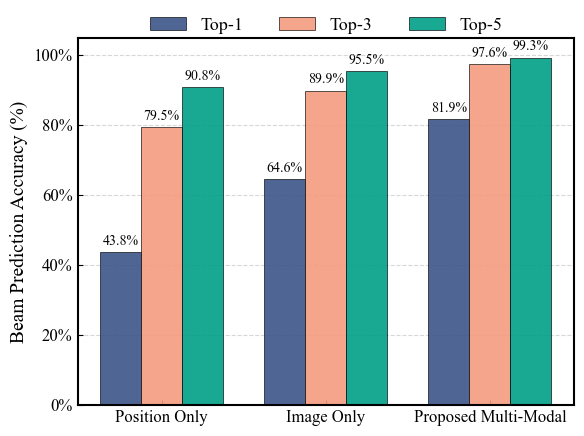

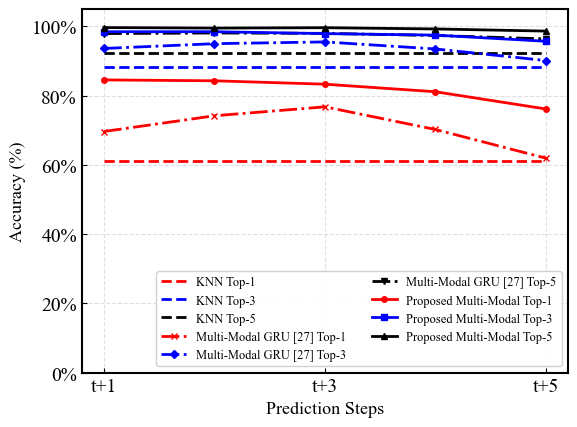

In [5]:
def plot_performance_bar_chart(results, save_path=RESULT_DIR / "modal_accuracy.pdf"):
    # Plot overall Top-1/3/5 accuracy for all models.
    setup_plot_style()
    models = [res["Model"] for res in results]
    top1 = [res["Top-1"] for res in results]
    top3 = [res["Top-3"] for res in results]
    top5 = [res["Top-5"] for res in results]

    x = np.arange(len(models))
    width = 0.25
    fig, ax = plt.subplots(figsize=(6, 4.5))
    rects1 = ax.bar(x - width, top1, width, label="Top-1", color="#3C5488", alpha=0.9, edgecolor="black", linewidth=0.5)
    rects2 = ax.bar(x, top3, width, label="Top-3", color="#F39B7F", alpha=0.9, edgecolor="black", linewidth=0.5)
    rects3 = ax.bar(x + width, top5, width, label="Top-5", color="#00A087", alpha=0.9, edgecolor="black", linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=12)
    ax.set_ylabel("Beam Prediction Accuracy (%)", fontsize=14)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
    ax.set_ylim(0, 1.05)
    ax.legend(loc="upper center", ncol=3, fontsize=13, frameon=False, bbox_to_anchor=(0.5, 1.10))
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

    for rects in (rects1, rects2, rects3):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f"{height:.1%}", xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()


def plot_accuracy_curve_with_knn(model_acc_results, save_path=RESULT_DIR / "acc_curve.pdf"):
    # Plot per-slot accuracy for selected multi-modal models and fixed KNN baselines.
    setup_plot_style(font_size=14)
    slots = np.arange(1, NUM_SLOTS + 1)
    fig, ax = plt.subplots(figsize=(6, 4.5))

    for k, color in zip((1, 3, 5), ("red", "blue", "black")):
        ax.plot(slots, [KNN_ACC[k]] * NUM_SLOTS, color=color, linestyle="--", linewidth=2, label=f"KNN Top-{k}")

    model_styles = {        
        "Multi-Modal GRU": {"linestyle": "-.", "markers": {1: "x", 3: "D", 5: "v"}, "zorder": 9},
        "Proposed Multi-Modal": {"linestyle": "-", "markers": {1: "o", 3: "s", 5: "^"}, "zorder": 10},
    }
    display_names = {"Multi-Modal GRU": "Multi-Modal GRU [27]"}
    for model_name, acc_results in model_acc_results.items():
        display_name = display_names.get(model_name, model_name)
        style = model_styles[model_name]
        for k, color in zip((1, 3, 5), ("red", "blue", "black")):
            ax.plot(slots, acc_results[k], label=f"{display_name} Top-{k}", color=color,
                    marker=style["markers"][k], markersize=4, linewidth=2,
                    linestyle=style["linestyle"], zorder=style["zorder"])

    ax.set_xlabel("Prediction Steps", fontsize=13)
    ax.set_ylabel("Accuracy (%)", fontsize=13)
    ax.set_xticks(slots[::2])
    ax.set_xticklabels([f"t+{i}" for i in slots[::2]])
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize=9, frameon=True, fancybox=True, framealpha=0.9, ncol=2, loc="lower right")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


outputs, labels = load_cached_outputs("Proposed Multi-Modal")
gru_outputs, gru_labels = load_cached_outputs("Multi-Modal GRU")
if not torch.equal(labels, gru_labels):
    raise ValueError("Cached GRU labels do not match the proposed model labels.")

model_acc_results = {    
    "Multi-Modal GRU": per_slot_topk(gru_outputs, labels),
    "Proposed Multi-Modal": per_slot_topk(outputs, labels),
}
plot_performance_bar_chart(accuracy_results)
plot_accuracy_curve_with_knn(model_acc_results)


## Confusion Matrices

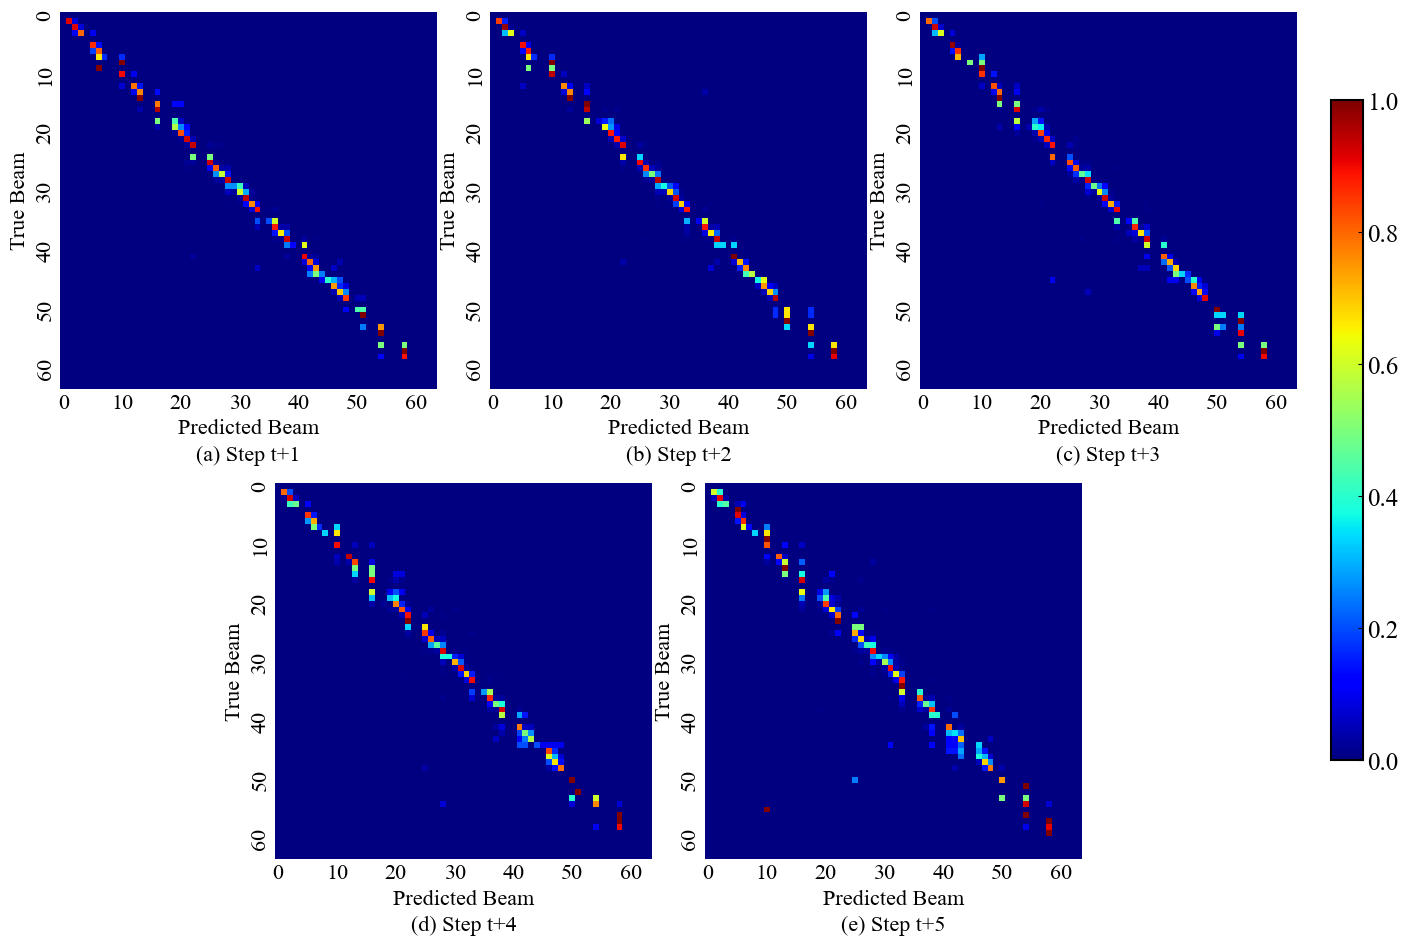

In [6]:
def compute_confusion_matrices(outputs, labels, num_classes=NUM_BEAMS):
    # Compute one normalized confusion matrix per prediction slot.
    matrices = []
    for slot in range(labels.size(1)):
        preds = outputs[:, slot, :].argmax(dim=1)
        cm = confusion_matrix(labels[:, slot].numpy(), preds.numpy(), labels=list(range(num_classes)))
        with np.errstate(divide="ignore", invalid="ignore"):
            cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-7)
        matrices.append(np.nan_to_num(cm_norm))
    return matrices


def plot_combined_confusion_matrices(cm_list, save_path=RESULT_DIR / "combined_cm.pdf"):
    # Plot all per-slot confusion matrices in one figure.
    setup_plot_style(font_size=14)
    fig = plt.figure(figsize=(16, 11))
    gs = gridspec.GridSpec(2, 6, figure=fig)
    axes = [
        fig.add_subplot(gs[0, 0:2]),
        fig.add_subplot(gs[0, 2:4]),
        fig.add_subplot(gs[0, 4:6]),
        fig.add_subplot(gs[1, 1:3]),
        fig.add_subplot(gs[1, 3:5]),
    ]
    sublabels = ["(a)", "(b)", "(c)", "(d)", "(e)"]

    for slot, ax in enumerate(axes):
        sns.heatmap(cm_list[slot], annot=False, cmap="jet", square=True,
                    xticklabels=10, yticklabels=10, ax=ax, cbar=False, vmin=0, vmax=1)
        ax.text(0.5, -0.15, f"{sublabels[slot]} Step t+{slot + 1}", transform=ax.transAxes,
                fontsize=16, ha="center", va="top")
        ax.set_xlabel("Predicted Beam", fontsize=16)
        ax.set_ylabel("True Beam", fontsize=16)
        ax.tick_params(axis="both", which="major", labelsize=16)
        ax.tick_params(length=0)

    cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
    sm = plt.cm.ScalarMappable(cmap="jet", norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.ax.tick_params(labelsize=18)
    plt.subplots_adjust(wspace=0.3, hspace=0.25, right=0.9)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()



cm_list = compute_confusion_matrices(outputs, labels)
plot_combined_confusion_matrices(cm_list)

## Speed, Distance, and Height Subset Analysis

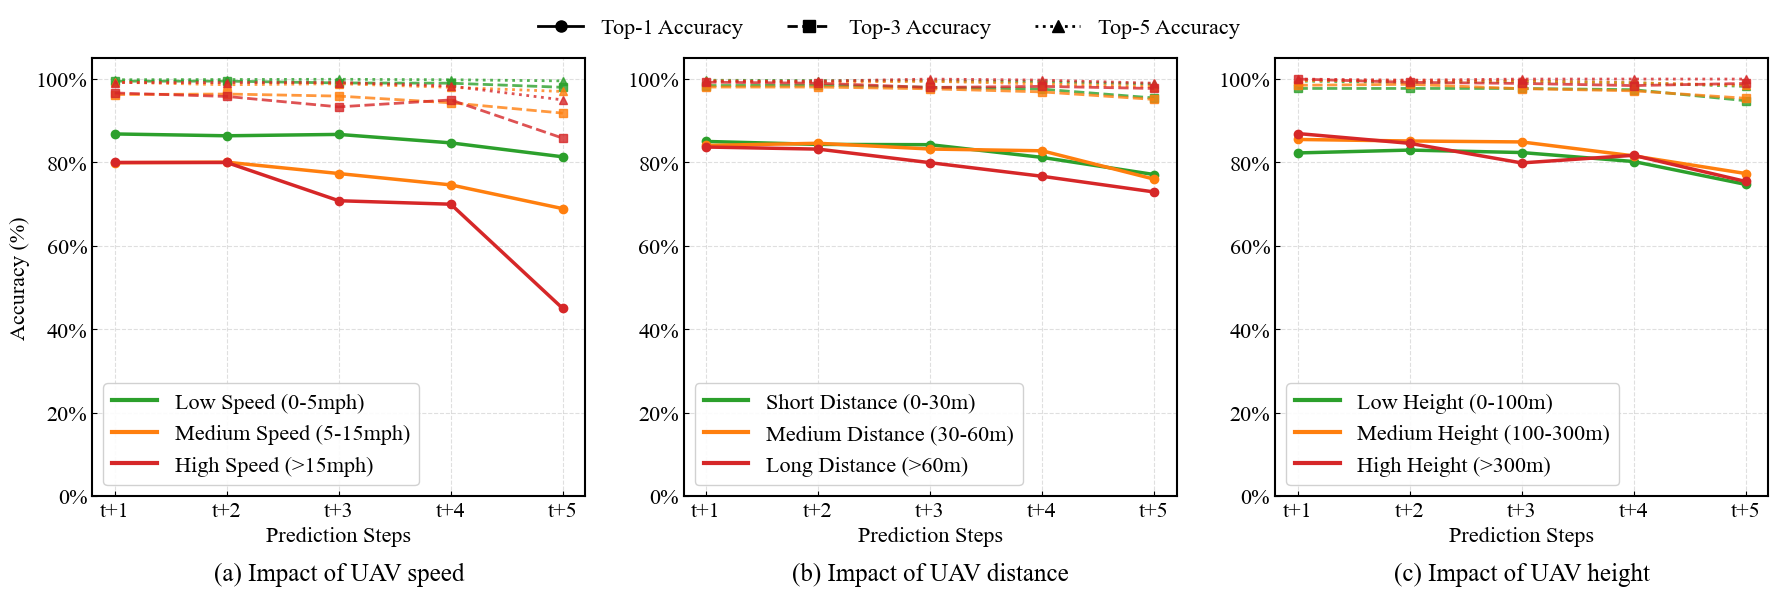

In [7]:
def get_indices_by_threshold(df, col_name, thresholds):
    # Split rows into low, medium, and high groups using two thresholds.
    values = df[col_name]
    return {
        "Low": df[values < thresholds[0]].index.tolist(),
        "Medium": df[(values >= thresholds[0]) & (values < thresholds[1])].index.tolist(),
        "High": df[values >= thresholds[1]].index.tolist(),
    }


def plot_subset_analysis(csv_path=TEST_CSV, outputs=outputs, labels=labels, save_path=RESULT_DIR / "speed_distance_height.pdf"):
    # Plot Top-K accuracy by speed, distance, and height groups.
    setup_plot_style(font_size=14)
    cols = ["current_speed", "current_distance", "current_height"]
    df = pd.read_csv(csv_path, usecols=cols)
    if len(df) != len(outputs):
        raise ValueError(f"CSV rows ({len(df)}) and cached outputs ({len(outputs)}) do not match.")

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    configs = [("Speed", "current_speed"), ("Distance", "current_distance"), ("Height", "current_height")]
    captions = ["(a) Impact of UAV speed", "(b) Impact of UAV distance", "(c) Impact of UAV height"]
    group_keys = ["Low", "Medium", "High"]
    slots = np.arange(1, NUM_SLOTS + 1)

    for subplot_idx, (attr_name, col_name) in enumerate(configs):
        ax = axes[subplot_idx]
        indices_map = get_indices_by_threshold(df, col_name, THRESHOLDS[attr_name])
        legend_lines = []

        for group_idx, group_key in enumerate(group_keys):
            idxs = indices_map[group_key]
            color = GROUP_COLORS[group_idx]
            legend_lines.append(Line2D([0], [0], color=color, lw=3, label=LEGEND_LABELS[attr_name][group_idx]))
            if not idxs:
                continue
            group_acc = per_slot_topk(outputs[idxs], labels[idxs])
            for k in (1, 3, 5):
                linestyle, marker = TOP_STYLES[k]
                ax.plot(slots, group_acc[k], color=color, ls=linestyle, marker=marker,
                        markersize=6, lw=2.5 if k == 1 else 2, alpha=1.0 if k == 1 else 0.8)

        ax.set_xlabel("Prediction Steps", fontsize=16)
        if subplot_idx == 0:
            ax.set_ylabel("Accuracy (%)", fontsize=16)
        ax.set_ylim(0.0, 1.05)
        ax.set_xticks(slots)
        ax.set_xticklabels([f"t+{i}" for i in slots], fontsize=16)
        ax.tick_params(axis="y", labelsize=16)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(handles=legend_lines, loc="lower left", fontsize=16, frameon=True, fancybox=True, framealpha=0.9)
        ax.text(0.5, -0.15, captions[subplot_idx], transform=ax.transAxes, fontsize=18, ha="center", va="top")

    top_legend = [
        Line2D([0], [0], color="black", ls=TOP_STYLES[k][0], marker=TOP_STYLES[k][1], markersize=8, lw=2, label=f"Top-{k} Accuracy")
        for k in (1, 3, 5)
    ]
    fig.legend(handles=top_legend, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.98), fontsize=16, frameon=False)
    plt.tight_layout()
    plt.subplots_adjust(top=0.88, bottom=0.15, wspace=0.2)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_feature_distributions(csv_path=TEST_CSV, save_dir=RESULT_DIR / "feature_distributions"):
    # Plot input feature distributions and mark the 33rd and 66th percentiles.
    setup_plot_style(font_size=12)
    save_dir.mkdir(parents=True, exist_ok=True)
    columns = ["current_speed", "current_distance", "current_height"]
    df = pd.read_csv(csv_path, usecols=columns)

    for column in columns:
        values = df[column].dropna()
        q33, q66 = values.quantile([0.33, 0.66])
        print(f"{column}: min={values.min():.4f}, max={values.max():.4f}, mean={values.mean():.4f}, std={values.std():.4f}")
        print(f"{column}: q33={q33:.4f}, q66={q66:.4f}")

        plt.figure(figsize=(6, 4))
        sns.histplot(values, bins=50, kde=True, color="#4C78A8", edgecolor="white")
        plt.axvline(q33, color="#F58518", linestyle="--", linewidth=2, label="33rd percentile")
        plt.axvline(q66, color="#E45756", linestyle="--", linewidth=2, label="66th percentile")
        plt.xlabel(column.replace("current_", "").title())
        plt.ylabel("Count")
        plt.grid(True, linestyle="--", alpha=0.35)
        plt.legend()
        plt.tight_layout()
        plt.savefig(save_dir / f"{column}_distribution.pdf", dpi=300, bbox_inches="tight")
        plt.show()


plot_subset_analysis()


## Measured Motion Regime Analysis

In [8]:
MOTION_REGIME_CSV = RESULT_DIR / "motion_regimes.csv"
MOTION_REGIME_STEP_METRICS_CSV = RESULT_DIR / "motion_regime_step_accuracy.csv"
MOTION_REGIME_STEP_METRICS_XLSX = RESULT_DIR / "motion_regime_step_accuracy.xlsx"
MOTION_REGIME_ORDER = ["Hovering-like", "Constant-speed-like", "Maneuvering"]
MOTION_MODEL_DISPLAY = {
    "Proposed Multi-Modal": "Proposed Multi-Modal",
    "Multi-Modal GRU": "Multi-Modal GRU [27]",
}


def parse_nested_numeric_series(raw):
    # Parse one CSV cell storing a list of per-frame scalar values.
    return np.asarray(ast.literal_eval(raw), dtype=float).reshape(-1)


def assign_motion_regime(mean_speed, speed_std):
    # Assign measured UAV motion regimes from the model-visible 8-frame history.
    if mean_speed < 1.0:
        return "Hovering-like"
    if mean_speed >= 1.0 and speed_std < 1.0:
        return "Constant-speed-like"
    return "Maneuvering"


def build_motion_regime_table(csv_path=TEST_CSV, save_path=MOTION_REGIME_CSV):
    # Build one motion-regime label per test sample without assuming rows are consecutive.
    df = pd.read_csv(csv_path, usecols=["unit2_speed"])
    rows = []
    for sample_idx, raw_speed in enumerate(df["unit2_speed"]):
        speed = parse_nested_numeric_series(raw_speed)
        mean_speed = float(np.mean(speed))
        speed_std = float(np.std(speed))
        mean_abs_speed_delta = float(np.mean(np.abs(np.diff(speed)))) if len(speed) > 1 else 0.0
        regime = assign_motion_regime(mean_speed, speed_std)
        rows.append({
            "sample_index": sample_idx,
            "mean_speed_mps": mean_speed,
            "speed_std_mps": speed_std,
            "mean_abs_speed_delta_mps": mean_abs_speed_delta,
            "motion_regime": regime,
        })

    regime_df = pd.DataFrame(rows)
    regime_df.to_csv(save_path, index=False)
    return regime_df


def step_topk_for_indices(outputs, labels, indices, topk=(1, 3, 5)):
    # Compute Top-K accuracy for each future prediction step on a subset of samples.
    if len(indices) == 0:
        return [{f"Top-{k}": np.nan for k in topk} for _ in range(NUM_SLOTS)]

    subset_outputs = outputs[indices]
    subset_labels = labels[indices]
    step_results = []
    for slot in range(NUM_SLOTS):
        accs = topk_accuracy(subset_outputs[:, slot, :], subset_labels[:, slot], topk)
        step_results.append({f"Top-{k}": acc for k, acc in zip(topk, accs)})
    return step_results


def compute_motion_regime_step_accuracy(regime_df, model_names=("Proposed Multi-Modal", "Multi-Modal GRU"),
                                        csv_path=MOTION_REGIME_STEP_METRICS_CSV,
                                        xlsx_path=MOTION_REGIME_STEP_METRICS_XLSX):
    # Compute per-step accuracy for each model and measured motion regime.
    rows = []
    for model_name in model_names:
        model_outputs, model_labels = load_cached_outputs(model_name)
        if len(regime_df) != len(model_outputs):
            raise ValueError(f"Motion-regime rows ({len(regime_df)}) and {model_name} outputs ({len(model_outputs)}) do not match.")
        for regime in MOTION_REGIME_ORDER:
            indices = regime_df.index[regime_df["motion_regime"] == regime].to_numpy()
            step_results = step_topk_for_indices(model_outputs, model_labels, indices)
            for slot, acc in enumerate(step_results, start=1):
                rows.append({
                    "Model": MOTION_MODEL_DISPLAY.get(model_name, model_name),
                    "Motion Regime": regime,
                    "Samples": int(len(indices)),
                    "Prediction Step": f"t+{slot}",
                    **acc,
                })

    metrics_df = pd.DataFrame(rows)
    metrics_df.to_csv(csv_path, index=False)
    
    return metrics_df


motion_regime_df = build_motion_regime_table()
motion_regime_step_metrics = compute_motion_regime_step_accuracy(motion_regime_df)
display(motion_regime_df["motion_regime"].value_counts().reindex(MOTION_REGIME_ORDER))
display(motion_regime_step_metrics)



motion_regime
Hovering-like           999
Constant-speed-like     652
Maneuvering            1101
Name: count, dtype: int64

,Model,Motion Regime,Samples,Prediction Step,Top-1,Top-3,Top-5
0,Proposed Multi-Modal,Hovering-like,999,t+1,0.883884,1.000000,1.000000
1,Proposed Multi-Modal,Hovering-like,999,t+2,0.868869,0.996997,1.000000
2,Proposed Multi-Modal,Hovering-like,999,t+3,0.873874,0.995996,1.000000
3,Proposed Multi-Modal,Hovering-like,999,t+4,0.863864,0.995996,0.998999
4,Proposed Multi-Modal,Hovering-like,999,t+5,0.831832,0.989990,0.996997
5,Proposed Multi-Modal,Constant-speed-like,652,t+1,0.832822,0.975460,0.996933
6,Proposed Multi-Modal,Constant-speed-like,652,t+2,0.846626,0.980061,0.995399
7,Proposed Multi-Modal,Constant-speed-like,652,t+3,0.832822,0.967791,0.995399
8,Proposed Multi-Modal,Constant-speed-like,652,t+4,0.788344,0.964724,0.990798
9,Proposed Multi-Modal,Constant-speed-like,652,t+5,0.726994,0.947853,0.984663


## Beam Power and RSRP Illustration Plots

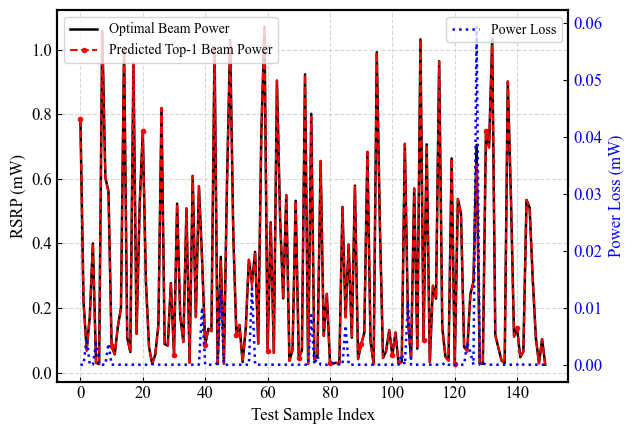

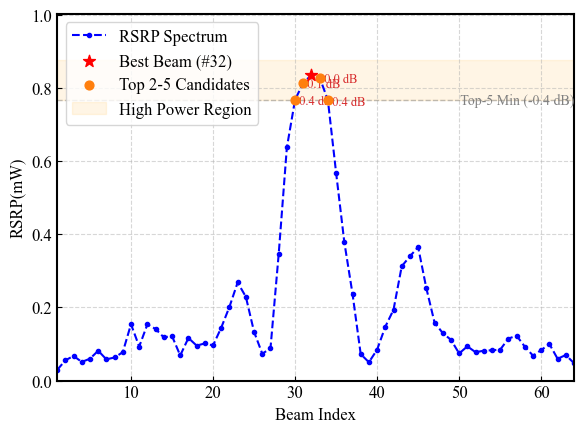

In [9]:
def parse_beam_powers(csv_path=TEST_CSV, slot=0, num_beams=NUM_BEAMS):
    # Parse the per-beam power column into an array with shape (num_samples, num_beams).
    df = pd.read_csv(csv_path, usecols=["unit1_pwr_60ghz"])
    powers = []
    for raw in tqdm(df["unit1_pwr_60ghz"], desc="Parsing beam powers", leave=False):
        try:
            values = ast.literal_eval(raw)[slot]
            values = (values + [0] * num_beams)[:num_beams]
            powers.append(values)
        except Exception:
            powers.append([0] * num_beams)
    return np.asarray(powers, dtype=float)


def plot_power_comparison_curve(outputs=outputs, csv_path=TEST_CSV, slot=0, num_samples=150,
                                save_path=RESULT_DIR / "power_comparison_curve.pdf"):
    # Compare optimal beam power with the predicted Top-1 beam power across samples.
    setup_plot_style()
    beam_powers = parse_beam_powers(csv_path=csv_path, slot=slot)
    pred_indices = outputs[:, slot, :].argmax(dim=1).cpu().numpy()
    usable = min(num_samples, len(beam_powers), len(pred_indices))
    beam_powers = beam_powers[:usable]
    pred_indices = pred_indices[:usable]

    optimal_powers = np.max(beam_powers, axis=1)
    predicted_powers = np.array([
        beam_powers[i, pred_idx] if 0 <= pred_idx < beam_powers.shape[1] else 0.0
        for i, pred_idx in enumerate(pred_indices)
    ])
    power_loss = optimal_powers - predicted_powers
    sample_indices = np.arange(usable)

    fig, ax1 = plt.subplots(figsize=(6.5, 4.5))
    ax1.plot(sample_indices, optimal_powers, "k-", linewidth=1.8, label="Optimal Beam Power")
    ax1.plot(sample_indices, predicted_powers, "r--", marker="o", markersize=3, markevery=10,
             linewidth=1.5, label="Predicted Top-1 Beam Power")
    ax1.set_xlabel("Test Sample Index", fontsize=12)
    ax1.set_ylabel("RSRP (mW)", fontsize=12)
    ax1.grid(True, linestyle="--", alpha=0.5)
    ax1.legend(loc="upper left", fontsize=10)

    ax2 = ax1.twinx()
    ax2.plot(sample_indices, power_loss, "b:", linewidth=1.8, label="Power Loss")
    ax2.set_ylabel("Power Loss (mW)", fontsize=12, color="blue")
    ax2.tick_params(axis="y", labelcolor="blue")
    ax2.legend(loc="upper right", fontsize=10)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_index_rsrp(csv_path=TEST_CSV, sample_idx=0, slot=4, save_path=RESULT_DIR / "index_rsrp.pdf"):
    # Plot one RSRP spectrum and highlight the Top-5 beams.
    setup_plot_style()
    raw = pd.read_csv(csv_path, usecols=["unit1_pwr_60ghz"]).iloc[sample_idx]["unit1_pwr_60ghz"]
    moment_data = np.asarray((ast.literal_eval(raw)[slot] + [0] * NUM_BEAMS)[:NUM_BEAMS], dtype=float)
    beam_indices = np.arange(1, len(moment_data) + 1)
    top5_indices_0based = np.argsort(moment_data)[-5:][::-1]
    top5_values = moment_data[top5_indices_0based]
    top5_indices_1based = top5_indices_0based + 1
    best_beam_val = max(top5_values[0], 1e-12)
    top5_db_drops = 10 * np.log10(np.maximum(top5_values, 1e-12) / best_beam_val)

    plt.figure(figsize=(6, 4.5))
    plt.plot(beam_indices, moment_data, linestyle="--", color="blue", marker=".", markersize=6,
             linewidth=1.5, label="RSRP Spectrum")
    plt.scatter(top5_indices_1based[0], top5_values[0], color="red", s=80, zorder=10,
                marker="*", label=f"Best Beam (#{top5_indices_1based[0]})")
    for i in range(1, 5):
        plt.scatter(top5_indices_1based[i], top5_values[i], color="#ff7f0e", s=40, zorder=9, marker="o")
        plt.text(top5_indices_1based[i], top5_values[i] - 0.021, f"{top5_db_drops[i]:.1f} dB",
                 ha="left", va="bottom", fontsize=9, color="#d62728")
    plt.scatter([], [], color="#ff7f0e", s=40, marker="o", label="Top 2-5 Candidates")
    plt.axhline(y=top5_values[-1], color="gray", linestyle="--", alpha=0.5, linewidth=1)
    plt.text(NUM_BEAMS, top5_values[-1], f" Top-5 Min ({top5_db_drops[-1]:.1f} dB)",
             va="center", ha="right", fontsize=10, color="gray")
    plt.fill_between(beam_indices, top5_values[-1], max(moment_data) * 1.05, alpha=0.1, color="orange",
                     label="High Power Region")
    plt.xlabel("Beam Index", fontsize=12)
    plt.ylabel("RSRP(mW)", fontsize=12)
    plt.xlim(1, NUM_BEAMS)
    plt.ylim(0, max(moment_data) * 1.2)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="upper left", fontsize=12)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_power_comparison_curve(slot=0, num_samples=150)
plot_index_rsrp(sample_idx=0, slot=4)


## Spectral Efficiency and Effective Throughput

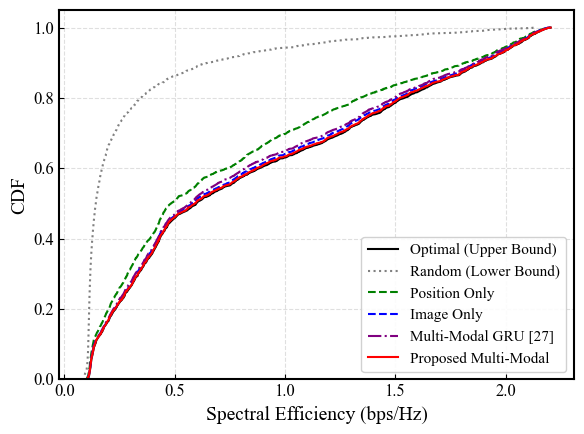

In [10]:
def calculate_se(power_watts, noise_watts):
    # Calculate SE = log2(1 + SNR).
    power_watts = np.maximum(np.asarray(power_watts, dtype=float), 1e-12)
    return np.log2(1 + power_watts / noise_watts)


def get_cdf_data(data):
    # Return sorted values and cumulative probability.
    sorted_data = np.sort(np.asarray(data, dtype=float))
    yvals = np.arange(len(sorted_data)) / max(float(len(sorted_data) - 1), 1.0)
    return sorted_data, yvals


def compute_predicted_se_from_cache(model_name, beam_powers, noise_power):
    # Convert cached first-slot predictions into spectral efficiency values.
    outputs, _ = load_cached_outputs(model_name)
    pred_indices = torch.argmax(outputs[:, 0, :], dim=1).numpy()
    sample_count = min(len(pred_indices), len(beam_powers))
    pred_powers = beam_powers[np.arange(sample_count), pred_indices[:sample_count]]
    return calculate_se(pred_powers, noise_power).tolist()


def compute_se_results():
    # Compute SE curves from cached logits and save the JSON result.
    beam_powers = parse_beam_powers(slot=0)
    avg_optimal_power = np.mean(np.max(beam_powers, axis=1))
    noise_power = avg_optimal_power / (10 ** (TARGET_SNR_DB / 10))

    results = {
        "Optimal": calculate_se(np.max(beam_powers, axis=1), noise_power).tolist(),
        "Random": calculate_se(beam_powers[np.arange(len(beam_powers)), np.random.randint(0, NUM_BEAMS, len(beam_powers))], noise_power).tolist(),
    }

    for config in INFERENCE_CONFIGS:
        results[config["name"]] = compute_predicted_se_from_cache(config["name"], beam_powers, noise_power)

    with SE_JSON.open("w", encoding="utf-8") as f:
        json.dump(results, f)
    return results


def plot_se_cdf(results, save_path=RESULT_DIR / "spectral_efficiency.pdf"):
    # Plot spectral efficiency CDF curves.
    setup_plot_style()
    plot_specs = [
        ("Optimal", "Optimal (Upper Bound)", "black", "-", 1.5),
        ("Random", "Random (Lower Bound)", "gray", ":", 1.5),
        ("Position Only", "Position Only", "green", "--", 1.5),
        ("Image Only", "Image Only", "blue", "--", 1.5),
        ("Multi-Modal GRU", "Multi-Modal GRU [27]", "purple", "-.", 1.5),
        ("Proposed Multi-Modal", "Proposed Multi-Modal", "red", "-", 1.5),
        
    ]

    plt.figure(figsize=(6, 4.5))
    for key, label, color, linestyle, linewidth in plot_specs:
        if key in results:
            x, y = get_cdf_data(results[key])
            plt.plot(x, y, label=label, color=color, linestyle=linestyle, linewidth=linewidth)
    plt.xlabel("Spectral Efficiency (bps/Hz)", fontsize=14)
    plt.ylabel("CDF", fontsize=14)
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(loc="lower right", fontsize=11, frameon=True, fancybox=True, framealpha=0.9)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()


se_results = compute_se_results()
plot_se_cdf(se_results)


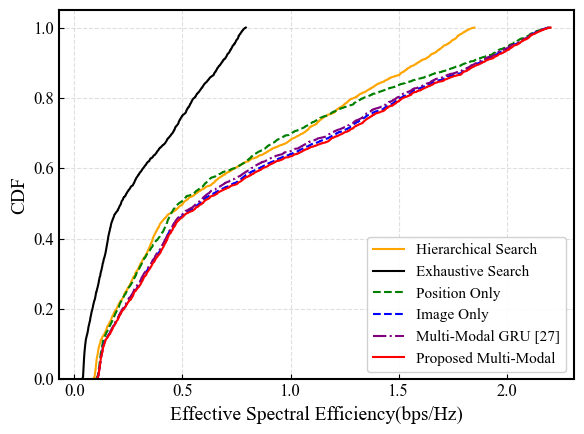

In [11]:
def compute_effective_throughput(se_results, t_total=100):
    # Convert SE curves into effective SE by applying beam-training overhead penalties.
    throughput = {}
    if "Optimal" in se_results:
        optimal = np.asarray(se_results["Optimal"], dtype=float)
        throughput["Exhaustive Search"] = (optimal * max(0, 1 - 64 / t_total)).tolist()
        throughput["Hierarchical Search"] = (optimal * max(0, 1 - 16 / t_total)).tolist()

    model_mapping = {
        "Proposed Multi-Modal": "Proposed Method",
        "Multi-Modal GRU": "Multi-Modal GRU",
        "Position Only": "Position Only",
        "Image Only": "Image Only",
    }
    for source_key, target_key in model_mapping.items():
        if source_key in se_results:
            throughput[target_key] = np.asarray(se_results[source_key], dtype=float).tolist()

    with THROUGHPUT_JSON.open("w", encoding="utf-8") as f:
        json.dump(throughput, f)
    return throughput


def plot_throughput_cdf(results, save_path=RESULT_DIR / "effective_throughput.pdf"):
    # Plot effective throughput CDF curves.
    setup_plot_style()
    plot_specs = [        
        ("Hierarchical Search", "Hierarchical Search", "orange", "-", 1.5),
        ("Exhaustive Search", "Exhaustive Search", "black", "-", 1.5),
        ("Position Only", "Position Only", "green", "--", 1.5),
        ("Image Only", "Image Only", "blue", "--", 1.5),
        ("Multi-Modal GRU", "Multi-Modal GRU [27]", "purple", "-.", 1.5),
        ("Proposed Method", "Proposed Multi-Modal", "red", "-", 1.5),
    ]

    plt.figure(figsize=(6, 4.5))
    for key, label, color, linestyle, linewidth in plot_specs:
        if key in results:
            x, y = get_cdf_data(results[key])
            plt.plot(x, y, label=label, color=color, linestyle=linestyle, linewidth=linewidth)
    plt.xlabel("Effective Spectral Efficiency(bps/Hz)", fontsize=14)
    plt.ylabel("CDF", fontsize=14)
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(loc="lower right", fontsize=11, frameon=True, fancybox=True, framealpha=0.9)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()


throughput_results = compute_effective_throughput(se_results)
plot_throughput_cdf(throughput_results)
